Name: Shubha Ghimire
ID: 2430050
6CS012 Worksheet 03 - Complete Solution

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Cell 2 — Task 1: MCP Neuron for AND Gate
def MCP_Neurons_AND(X1, X2, T):
    """
    This function implements basic AND operations with MCP Neuron for two inputs.

    Arguments:
    X1 (1D array): An array of binary values
    X2 (1D array): An array of binary values
    T (int): Threshold value

    Output:
    state_neuron (list): Output state of neuron (1 or 0)
    """
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        summation = X1[i] + X2[i]
        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [3]:
# Cell 3 — Test AND Gate
# Example usage for MCP_Neurons_AND function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2  # Threshold value for AND gate

result_and = MCP_Neurons_AND(X1, X2, T)
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result_and}")

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [4]:
# Cell 4 — Task 1: MCP Neuron for OR Gate
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.

    Arguments:
    X1 (1D array): An array of binary values
    X2 (1D array): An array of binary values
    T (int): Threshold value

    Output:
    state_neuron (list): Output state of neuron (1 or 0)
    """
    assert len(X1) == len(X2)

    state_neuron = []

    for i in range(len(X1)):
        summation = X1[i] + X2[i]
        if summation >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

In [5]:
# Cell 5 - Test OR Gate
# Example usage for MCP_Neurons_OR function
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1  # Threshold value for OR gate

result_or = MCP_Neurons_OR(X1, X2, T)
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


In [6]:
# Cell 6 - Theory Answers for Task 1
print("1. Why can MCP neuron solve AND and OR?")
print("Because MCP neuron uses weighted sum and thresholding, which works for linearly separable problems like AND and OR.\n")

print("2. Why can MCP neuron not solve XOR?")
print("Because XOR is not linearly separable, so a single MCP neuron cannot classify it correctly.\n")

print("3. Limitations of MCP neuron:")
print("- It can only solve linearly separable problems.")
print("- It cannot learn complex decision boundaries.")
print("- It uses a simple threshold activation.")
print("- A single neuron is not enough for problems like XOR.")

1. Why can MCP neuron solve AND and OR?
Because MCP neuron uses weighted sum and thresholding, which works for linearly separable problems like AND and OR.

2. Why can MCP neuron not solve XOR?
Because XOR is not linearly separable, so a single MCP neuron cannot classify it correctly.

3. Limitations of MCP neuron:
- It can only solve linearly separable problems.
- It cannot learn complex decision boundaries.
- It uses a simple threshold activation.
- A single neuron is not enough for problems like XOR.


In [7]:
# Cell 7 - load MNIST 0 v 1 Dataset
df_01 = pd.read_csv("/content/drive/MyDrive/Level 6 AI/week3/mnist_0_and_1.csv")
df_01.head()

,label,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
# Cell 8 — Check shape and basic info
print("Shape of mnist_0_and_1 dataset:", df_01.shape)
print("\nClass distribution:")
print(df_01["label"].value_counts())

Shape of mnist_0_and_1 dataset: (12665, 785)

Class distribution:
label
1    6742
0    5923
Name: count, dtype: int64


In [9]:
# Cell 9 — Prepare features and labels for 0 vs 1
X_01 = df_01.drop("label", axis=1).values
y_01 = df_01["label"].values

# Normalize pixel values
X_01 = X_01 / 255.0

print("Feature matrix shape:", X_01.shape)
print("Target vector shape:", y_01.shape)

Feature matrix shape: (12665, 784)
Target vector shape: (12665,)


In [10]:
# Cell 10 - split dataset into train and test
X_train_01, X_test_01, y_train_01, y_test_01 = train_test_split(
    X_01, y_01, test_size=0.2, random_state=42, stratify=y_01
)

print("Training set shape:", X_train_01.shape)
print("Testing set shape:", X_test_01.shape)

Training set shape: (10132, 784)
Testing set shape: (2533, 784)


In [11]:
# Cell 11 — Perceptron prediction function
def perceptron_predict(X, weights, bias):
    """
    Predict class labels using perceptron rule.
    """
    linear_output = np.dot(X, weights) + bias
    return np.where(linear_output >= 0, 1, 0)

In [12]:
# Cell 12 — Perceptron training function
def train_perceptron(X, y, learning_rate=0.01, epochs=20):
    """
    Train perceptron model.

    Parameters:
    X : feature matrix
    y : target labels
    learning_rate : learning rate
    epochs : number of passes through dataset

    Returns:
    weights, bias, errors_per_epoch
    """
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0
    errors_per_epoch = []

    for epoch in range(epochs):
        errors = 0

        for i in range(n_samples):
            linear_output = np.dot(X[i], weights) + bias
            y_pred = 1 if linear_output >= 0 else 0

            update = learning_rate * (y[i] - y_pred)

            if update != 0:
                weights += update * X[i]
                bias += update
                errors += 1

        errors_per_epoch.append(errors)
        print(f"Epoch {epoch+1}/{epochs}, Errors: {errors}")

    return weights, bias, errors_per_epoch

In [13]:
# Cell 13 — Train perceptron for 0 vs 1
weights_01, bias_01, errors_01 = train_perceptron(
    X_train_01, y_train_01, learning_rate=0.01, epochs=20
)

Epoch 1/20, Errors: 41
Epoch 2/20, Errors: 14
Epoch 3/20, Errors: 16
Epoch 4/20, Errors: 13
Epoch 5/20, Errors: 14
Epoch 6/20, Errors: 15
Epoch 7/20, Errors: 4
Epoch 8/20, Errors: 7
Epoch 9/20, Errors: 5
Epoch 10/20, Errors: 1
Epoch 11/20, Errors: 0
Epoch 12/20, Errors: 0
Epoch 13/20, Errors: 0
Epoch 14/20, Errors: 0
Epoch 15/20, Errors: 0
Epoch 16/20, Errors: 0
Epoch 17/20, Errors: 0
Epoch 18/20, Errors: 0
Epoch 19/20, Errors: 0
Epoch 20/20, Errors: 0


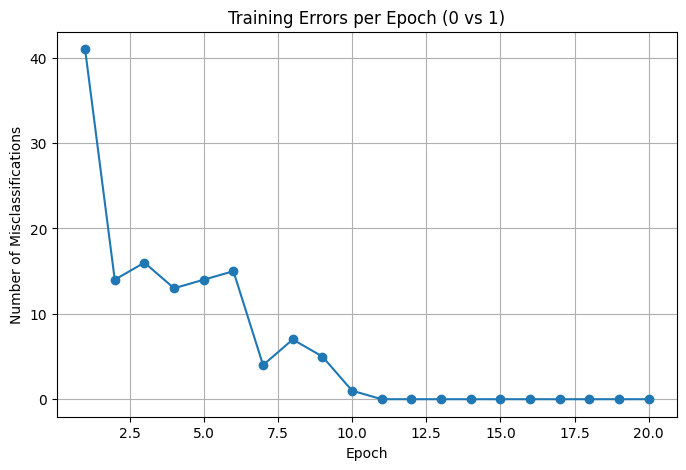

In [14]:
# Cell 14 — Plot training errors
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(errors_01) + 1), errors_01, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Number of Misclassifications")
plt.title("Training Errors per Epoch (0 vs 1)")
plt.grid(True)
plt.show()

In [15]:
# Cell 15 — Predict on test set and calculate accuracy
y_pred_01 = perceptron_predict(X_test_01, weights_01, bias_01)
accuracy_01 = accuracy_score(y_test_01, y_pred_01)

print("Accuracy for 0 vs 1 classification:", accuracy_01)


Accuracy for 0 vs 1 classification: 0.9984208448480063


In [16]:
# Cell 16 — Confusion matrix and report
print("Confusion Matrix:")
print(confusion_matrix(y_test_01, y_pred_01))

print("\nClassification Report:")
print(classification_report(y_test_01, y_pred_01))

Confusion Matrix:
[[1183    2]
 [   2 1346]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1185
           1       1.00      1.00      1.00      1348

    accuracy                           1.00      2533
   macro avg       1.00      1.00      1.00      2533
weighted avg       1.00      1.00      1.00      2533



In [17]:
# Cell 17 — Show some misclassified images for 0 vs 1
misclassified_indices_01 = np.where(y_test_01 != y_pred_01)[0]
print("Number of misclassified samples:", len(misclassified_indices_01))

Number of misclassified samples: 4


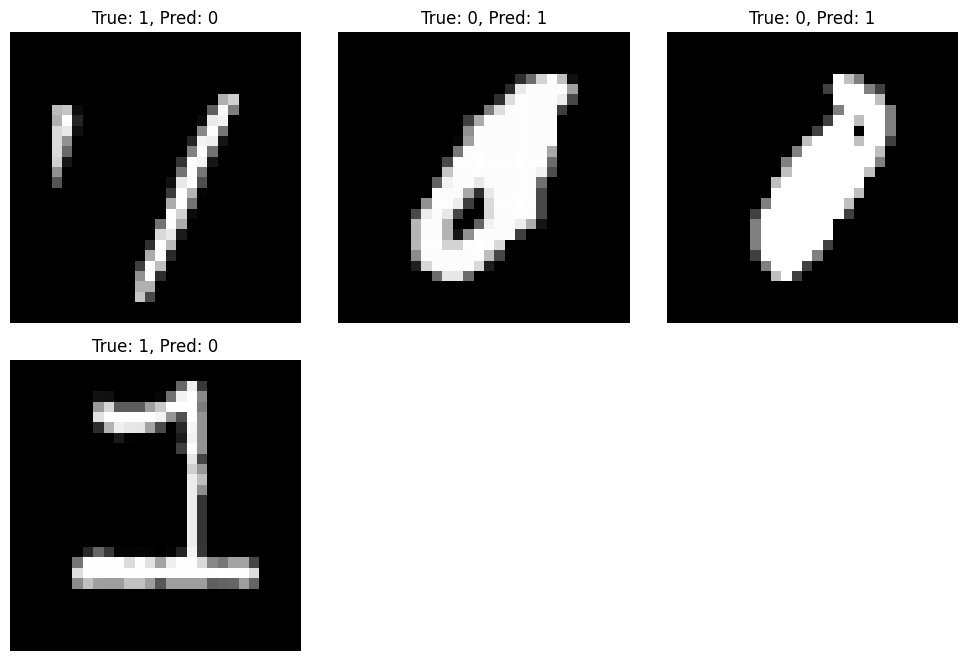

In [18]:
# Cell 18 — Visualize misclassified images for 0 vs 1
num_images = min(9, len(misclassified_indices_01))

plt.figure(figsize=(10, 10))
for i in range(num_images):
    idx = misclassified_indices_01[i]
    image = X_test_01[idx].reshape(28, 28)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"True: {y_test_01[idx]}, Pred: {y_pred_01[idx]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
# Cell 19 - Load MNIST 3 vs 5 Dataset
df_35 = pd.read_csv("/content/drive/MyDrive/Level 6 AI/week3/mnist_3_and_5.csv")
df_35.head()

,label,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_774,pixel_775,pixel_776,pixel_777,pixel_778,pixel_779,pixel_780,pixel_781,pixel_782,pixel_783
0,5,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
# Cell 20 — Check shape and class distribution
print("Shape of mnist_3_and_5 dataset:", df_35.shape)
print("\nClass distribution:")
print(df_35["label"].value_counts())

Shape of mnist_3_and_5 dataset: (2741, 785)

Class distribution:
label
3    1484
5    1257
Name: count, dtype: int64


In [21]:
# Cell 21 — Prepare features and labels for 3 vs 5
X_35 = df_35.drop("label", axis=1).values
y_35_raw = df_35["label"].values

# Convert labels: 3 -> 0, 5 -> 1
y_35 = np.where(y_35_raw == 3, 0, 1)

# Normalize pixel values
X_35 = X_35 / 255.0

print("Feature matrix shape:", X_35.shape)
print("Target vector shape:", y_35.shape)

Feature matrix shape: (2741, 784)
Target vector shape: (2741,)


In [22]:
# Cell 22 — Split dataset into train and test
X_train_35, X_test_35, y_train_35, y_test_35 = train_test_split(
    X_35, y_35, test_size=0.2, random_state=42, stratify=y_35
)

print("Training set shape:", X_train_35.shape)
print("Testing set shape:", X_test_35.shape)


Training set shape: (2192, 784)
Testing set shape: (549, 784)


In [23]:
# Cell 23 — Train perceptron for 3 vs 5
weights_35, bias_35, errors_35 = train_perceptron(
    X_train_35, y_train_35, learning_rate=0.01, epochs=20
)

Epoch 1/20, Errors: 233
Epoch 2/20, Errors: 149
Epoch 3/20, Errors: 122
Epoch 4/20, Errors: 134
Epoch 5/20, Errors: 111
Epoch 6/20, Errors: 109
Epoch 7/20, Errors: 95
Epoch 8/20, Errors: 100
Epoch 9/20, Errors: 100
Epoch 10/20, Errors: 91
Epoch 11/20, Errors: 91
Epoch 12/20, Errors: 75
Epoch 13/20, Errors: 72
Epoch 14/20, Errors: 86
Epoch 15/20, Errors: 80
Epoch 16/20, Errors: 75
Epoch 17/20, Errors: 62
Epoch 18/20, Errors: 67
Epoch 19/20, Errors: 71
Epoch 20/20, Errors: 71


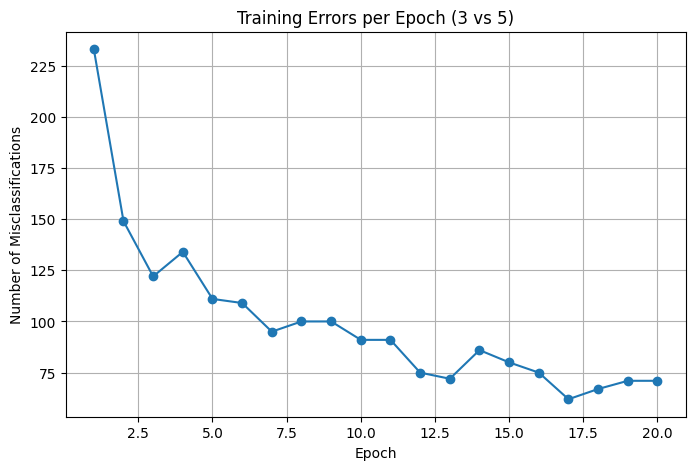

In [24]:
# Cell 24 — Plot training errors for 3 vs 5
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(errors_35) + 1), errors_35, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Number of Misclassifications")
plt.title("Training Errors per Epoch (3 vs 5)")
plt.grid(True)
plt.show()

In [25]:
# Cell 25 — Predict on test set and calculate accuracy
y_pred_35 = perceptron_predict(X_test_35, weights_35, bias_35)
accuracy_35 = accuracy_score(y_test_35, y_pred_35)

print("Accuracy for 3 vs 5 classification:", accuracy_35)

Accuracy for 3 vs 5 classification: 0.9526411657559198


In [26]:
# Cell 26 — Confusion matrix and report
print("Confusion Matrix:")
print(confusion_matrix(y_test_35, y_pred_35))

print("\nClassification Report:")
print(classification_report(y_test_35, y_pred_35))

Confusion Matrix:
[[283  14]
 [ 12 240]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96       297
           1       0.94      0.95      0.95       252

    accuracy                           0.95       549
   macro avg       0.95      0.95      0.95       549
weighted avg       0.95      0.95      0.95       549



In [27]:
# Cell 27 — Show misclassified samples for 3 vs 5
misclassified_indices_35 = np.where(y_test_35 != y_pred_35)[0]
print("Number of misclassified samples:", len(misclassified_indices_35))

Number of misclassified samples: 26


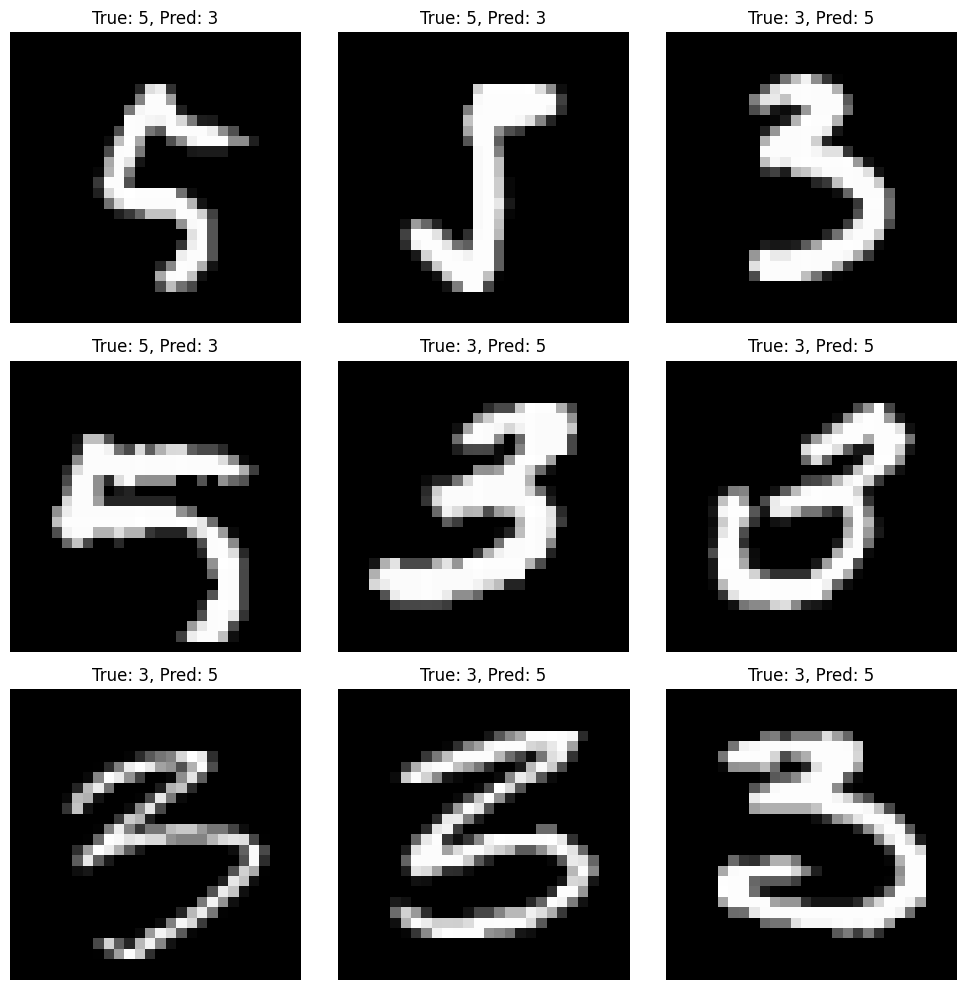

In [28]:
# Cell 28 — Visualize misclassified images for 3 vs 5
num_images = min(9, len(misclassified_indices_35))

plt.figure(figsize=(10, 10))
for i in range(num_images):
    idx = misclassified_indices_35[i]
    image = X_test_35[idx].reshape(28, 28)

    true_label = 3 if y_test_35[idx] == 0 else 5
    pred_label = 3 if y_pred_35[idx] == 0 else 5

    plt.subplot(3, 3, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(f"True: {true_label}, Pred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [29]:
# Cell 29 — Final conclusion
print("Conclusion:")
print("1. MCP neuron successfully performs AND and OR operations.")
print("2. MCP neuron cannot solve XOR because XOR is not linearly separable.")
print("3. Perceptron performed well on 0 vs 1 classification.")
print("4. Perceptron was also applied to 3 vs 5 classification, which is more difficult than 0 vs 1.")
print("5. Misclassified images help us understand where the model makes mistakes.")

Conclusion:
1. MCP neuron successfully performs AND and OR operations.
2. MCP neuron cannot solve XOR because XOR is not linearly separable.
3. Perceptron performed well on 0 vs 1 classification.
4. Perceptron was also applied to 3 vs 5 classification, which is more difficult than 0 vs 1.
5. Misclassified images help us understand where the model makes mistakes.
